# Binary Stellar Evolution Endpoints – Tutorial

We're going to take a look at a very basic population synthesis, looking specifically at stellar endpoints in the BPASS v2.2 binary stellar evolution grid (Eldridge et al 2017, Stanway et al 2018). For simplicity, we're only considering single stars and the primary stars in binaries here (i.e. not secondaries or post-SN evolution). 

In this tutorial we will:
1. Read information already gathered from the **last lines** of a grid of binary stellar evolution models into NumPy arrays. The endpoints are the last step in the stellar evolution model before it fails due to extreme conditions; usually within a year or two of supernova and so providing a good model for the stellar properties at that point.
2. Choose which **population type** to study (single stars, close binaries, or all systems)
3. Construct a basic **Initial Mass Function (IMF)** weighting array $\Phi$ normalised over that population
4. Apply further constraints to select a sub-sample of models
5. Explore three properties of the selected sample:
   - (i) The total IMF weight of the selection
   - (ii) The distribution of stellar ages
   - (iii) The distribution of surface hydrogen (XH) and helium (XY) abundances

After working through these steps you can consider more complex selections and properties.

---
### Column descriptions

| Column | Description |
|---|---|
| `Metallicity` | Initial metallicity Z |
| `M1in` | Initial primary mass (M☉) |
| `M2in` | Initial secondary mass (M☉) |
| `Pin` | Initial orbital period (days) |
| `M1` | Current primary mass (M☉) |
| `logAge` | log₁₀ age at endpoint (yr) |
| `HeCore` | Helium core mass (M☉) |
| `COCore` | Carbon-oxygen core mass (M☉) |
| `logR` | log₁₀ radius (R☉) |
| `logT` | log₁₀ effective temperature (K) |
| `logL` | log₁₀ luminosity (L☉) |
| `M1fin` | Final primary mass (M☉) |
| `XH` | Surface hydrogen mass fraction |
| `XY` | Surface helium mass fraction |
| `XC` | Surface carbon mass fraction |
| `MH` | Hydrogen envelope mass (M☉) |
| `MHe` | Helium envelope mass (M☉) |

Note: for further definition, see the [BPASS v2.2 manual online](https://warwick.ac.uk/fac/sci/physics/research/astro/research/catalogues/bpass/v2p2/bpassv2.2_manual-arial.pdf)

---
## 1  –  Reading the data

The file (generated for the purposes of this tutorial to avoid you having to download gigabytes of data) is fixed-width with format (f7.3, 2x, 16(f12.6, 2x)). Separate files are provided for three metallicities; z001, z010, z020 where z020 implies a total metallicity mass fraction Z=0.020 (i.e. ~Solar).


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --------------------------------------------------------------------------
# File path – update this to match the location of your data file
# --------------------------------------------------------------------------
FILENAME = 'endpoints_z020.txt'

# Column names matching the Fortran format (f7.3, 2x, 16(f12.6, 2x))
COL_NAMES = [
    'Metallicity', 'M1in', 'M2in', 'Pin',
    'M1', 'logAge', 'HeCore', 'COCore',
    'logR', 'logT', 'logL', 'M1fin',
    'XH', 'XY', 'XC', 'MH', 'MHe'
]

# Read lines, replacing '-Inf' / 'Inf' with nan-compatible strings
rows = []
with open(FILENAME, 'r') as f:
    for line in f:
        line = line.replace('-Inf', 'nan').replace('Inf', 'nan')
        values = line.split()
        if len(values) == len(COL_NAMES):
            rows.append([float(v) for v in values])

data = np.array(rows)          # shape: (N_rows, 17)

# Unpack each column into its own 1-D array
(
    Metallicity, M1in, M2in, Pin,
    M1, logAge, HeCore, COCore,
    logR, logT, logL, M1fin,
    XH, XY, XC, MH, MHe
) = data.T

print(f'Loaded {data.shape[0]} rows and {data.shape[1]} columns.')
print(f'Columns: {COL_NAMES}')
print(f'\nFirst row: {data[0]}')
print(f'\nM1in range : {M1in.min():.3f} – {M1in.max():.3f} M☉')
print(f'logAge range: {np.nanmin(logAge):.3f} – {np.nanmax(logAge):.3f}')

Loaded 12947 rows and 17 columns.
Columns: ['Metallicity', 'M1in', 'M2in', 'Pin', 'M1', 'logAge', 'HeCore', 'COCore', 'logR', 'logT', 'logL', 'M1fin', 'XH', 'XY', 'XC', 'MH', 'MHe']

First row: [ 2.0000e-02  1.0000e-01  1.0000e+00  3.0279e+08  1.0000e-01  1.1131e+01
  0.0000e+00  0.0000e+00 -8.5961e-01  3.4454e+00 -2.9845e+00  1.0000e-01
  6.8661e-01  2.9339e-01  3.4603e-03  6.8660e-02  9.9999e+04]

M1in range : 0.100 – 330.000 M☉
logAge range: 5.071 – 99999.000


---
## 2  –  Choosing the population type

Before constructing the IMF weights, we restrict the grid to a single **population type**.  
The grid encodes three kinds of system via the initial secondary mass `M2in` and orbital period `Pin`:

| Population | Definition | `POPULATION` value |
|---|---|---|
| Single stars | `M2in < 0.01` | `'single'` |
| Close binaries | `M2in >= 0.1` **and** `Pin < 1` day | `'close'` |
| All systems | No filter | `'all'` |

> **Set `POPULATION` in the cell below**, then run it.  
> All subsequent arrays — including $\Phi$ — will be normalised over this sub-population only.

In [32]:
# ---------------------------------------------------------------
# >>> SET YOUR POPULATION TYPE HERE <<<
#
# Options:
#   'single'  – single stars only        (M2in < 0.01)
#   'close'   – close binaries only      (M2in >= 0.1 and Pin < 1 day)
#   'all'     – all systems in the grid
# ---------------------------------------------------------------
POPULATION = 'all'   # <-- change this

# ---------------------------------------------------------------
# Apply the population filter – do not modify below this line
# ---------------------------------------------------------------
if POPULATION == 'single':
    pop_mask = M2in < 0.01
    pop_label = 'Single stars (M2in < 0.01 M☉)'
elif POPULATION == 'close':
    pop_mask = (M2in >= 0.1) & (Pin < 1.0)
    pop_label = 'Close binaries (M2in ≥ 0.1 M☉, Pin < 1 d)'
elif POPULATION == 'all':
    pop_mask = np.ones(len(M1in), dtype=bool)
    pop_label = 'All systems'
else:
    raise ValueError(f"Unknown POPULATION '{POPULATION}'. Choose 'single', 'close', or 'all'.")

# Restrict all column arrays to the chosen population
(
    Metallicity, M1in, M2in, Pin,
    M1, logAge, HeCore, COCore,
    logR, logT, logL, M1fin,
    XH, XY, XC, MH, MHe
) = data[pop_mask].T

print(f'Population : {pop_label}')
print(f'Rows retained: {pop_mask.sum()} / {len(pop_mask)}')
print(f'M1in range : {M1in.min():.3f} – {M1in.max():.3f} M☉')
print(f'M2in range : {M2in.min():.3f} – {M2in.max():.3f} M☉')
print(f'Pin  range : {Pin.min():.4f} – {Pin.max():.3f} days')

Population : All systems
Rows retained: 12947 / 12947
M1in range : 0.100 – 330.000 M☉
M2in range : 0.000 – 270.890 M☉
Pin  range : 0.0000 – 677060000.000 days


---
## 3  –  Constructing the IMF weight $\Phi$

We model the primary-mass distribution with a **power-law Initial Mass Function**:

$$\Phi_i \;=\; M_{1,\mathrm{in},i}^{\,\alpha}$$

where $\alpha$ is the IMF slope index. The classical Salpeter (1955) value is $\alpha = -2.35$.  
After computing $\Phi$, we normalise so that the **total weight over the chosen population sums to 1**.

Note that this is something of an oversimplification: if the stars were all single and the models were on a regular grid, it would be fine. However for irregularly gridded model data, or for binary populations, a formal IMF normalisation integral needs to reflect the mass interval between models, dM, and also the relative weighting of single versus binary models, and of models as a function of initial period and mass ratio. Most populations will also exhibit a turn over in mass below 1 M☉ which we are neglecting here.

> **Set your chosen value of `alpha` in the cell below.**

In [33]:
# ---------------------------------------------------------------
# >>> SET YOUR IMF SLOPE HERE <<<
# Salpeter (1955): alpha = -2.35
# Kroupa (2001) high-mass slope: alpha = -2.3
# ---------------------------------------------------------------
alpha = -2.35

# Compute raw IMF weights and normalise over the chosen population
Phi_raw = M1in ** alpha
Phi = Phi_raw / Phi_raw.sum()

print(f'Population : {pop_label}')
print(f'alpha = {alpha}')
print(f'Sum of Phi (should be 1.0): {Phi.sum():.6f}')
print(f'Min / Max Phi: {Phi.min():.4e} / {Phi.max():.4e}')

Population : All systems
alpha = -2.35
Sum of Phi (should be 1.0): 1.000000
Min / Max Phi: 2.0238e-11 / 3.7556e-03


---
## 4  –  Selecting a sub-sample

Now it is your turn.  
In the cell below, **define a boolean mask** called `mask` that selects the rows you are interested in *within the chosen population*.

You can combine conditions using `&` (AND), `|` (OR) and `~` (NOT).  
All column arrays are already available by name.

**Example constraints you might consider:**
- A range of initial primary mass: `(M1in >= 5.0) & (M1in <= 20.0)`
- A metallicity value: `Metallicity == 0.001`
- Stars that retained a hydrogen envelope: `XH > 0.1`
- Stars with a finite age: `np.isfinite(logAge)`
- A period range: `(Pin >= 1.0) & (Pin <= 100.0)`

In [34]:
# ---------------------------------------------------------------
# >>> DEFINE YOUR SELECTION MASK HERE <<<
#
# Example (select all rows with finite ages and M1in >= 1 M☉):
#   mask = np.isfinite(logAge) & (M1in >= 1.0)
# ---------------------------------------------------------------
mask = (M1in >= 5.0) & (M1in <= 20.0)   # <-- replace this with your condition(s)

# ---------------------------------------------------------------
# Do not modify below this line
# ---------------------------------------------------------------
assert isinstance(mask, np.ndarray) and mask.dtype == bool, \
    "mask must be a boolean NumPy array"

n_selected = mask.sum()
print(f'Population : {pop_label}')
print(f'Rows selected : {n_selected} / {len(mask)}')
print(f'Fraction      : {n_selected / len(mask):.3f}')

Population : All systems
Rows selected : 4030 / 12947
Fraction      : 0.311


---
## Exercise (i)  –  Total IMF weight of the selection

The total weight $W$ of the selected sub-sample tells us what fraction of the chosen population (weighted by the IMF) falls within your constraints:

$$W = \sum_{i \in \mathrm{selection}} \Phi_i$$

Because $\Phi$ is normalised over the chosen population, $W$ is directly interpretable as a probability or relative frequency **within that population**.

In [35]:
# Total IMF weight of selected rows
W = Phi[mask].sum()

print(f'Population : {pop_label}')
print(f'Total IMF weight of selection  W = {W:.6f}')
print(f'This means {W*100:.2f}% of the IMF-weighted {POPULATION} population satisfies your constraints.')

Population : All systems
Total IMF weight of selection  W = 0.000437
This means 0.04% of the IMF-weighted all population satisfies your constraints.


---
## Exercise (ii)  –  Age distribution

We plot the distribution of $\log_{10}(\mathrm{Age})$ for the selected rows, weighting each bin by the sum of $\Phi_i$ within it.  
Rows with `logAge = NaN` (effectively infinite lifetime on the grid) are excluded from the histogram but counted separately.

The weighted mean age is:

$$\langle \log_{10} t \rangle = \frac{\displaystyle\sum_{i \in \mathrm{finite}} \Phi_i \, \log_{10} t_i}{\displaystyle\sum_{i \in \mathrm{finite}} \Phi_i}$$

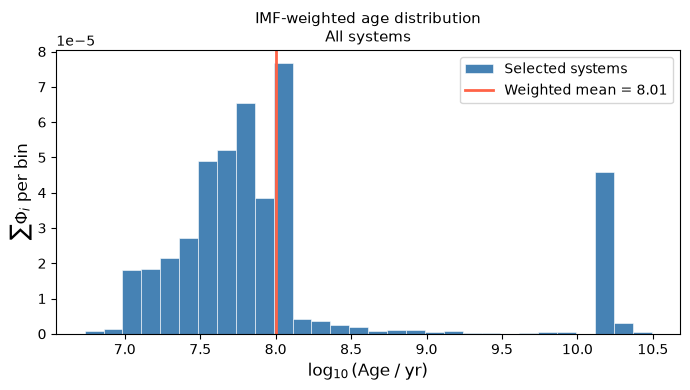

Weighted mean log Age = 8.005
Rows with finite age  : 4030
Rows with NaN age     : 0


In [36]:
# Restrict to selected rows with finite ages
finite_age = mask & np.isfinite(logAge)
n_nan = mask.sum() - finite_age.sum()

logAge_sel = logAge[finite_age]
Phi_sel    = Phi[finite_age]

# Weighted mean log age
mean_logAge = np.average(logAge_sel, weights=Phi_sel)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(logAge_sel, bins=30, weights=Phi_sel,
        color='steelblue', edgecolor='white', linewidth=0.4, label='Selected systems')
ax.axvline(mean_logAge, color='tomato', linewidth=2,
           label=f'Weighted mean = {mean_logAge:.2f}')
ax.set_xlabel(r'$\log_{10}(\mathrm{Age} \;/\; \mathrm{yr})$', fontsize=12)
ax.set_ylabel(r'$\sum \Phi_i$ per bin', fontsize=12)
ax.set_title(f'IMF-weighted age distribution\n{pop_label}', fontsize=11)
ax.legend()
if n_nan > 0:
    ax.text(0.98, 0.95, f'{n_nan} rows with logAge = NaN excluded',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='grey')
plt.tight_layout()
plt.show()

print(f'Weighted mean log Age = {mean_logAge:.3f}')
print(f'Rows with finite age  : {finite_age.sum()}')
print(f'Rows with NaN age     : {n_nan}')

---
## Exercise (iii)  –  Surface composition: XH and XY distributions

We now look at the **surface hydrogen** (`XH`) and **surface helium** (`XY`) mass fractions of the selected models. These tell us whether stars have retained their envelopes (high XH) or have been stripped (low XH, high XY).

We plot:
- **Left**: IMF-weighted histograms of XH and XY overlaid for easy comparison
- **Right**: A 2-D scatter of XH vs XY, coloured by initial primary mass $M_{1,\mathrm{in}}$

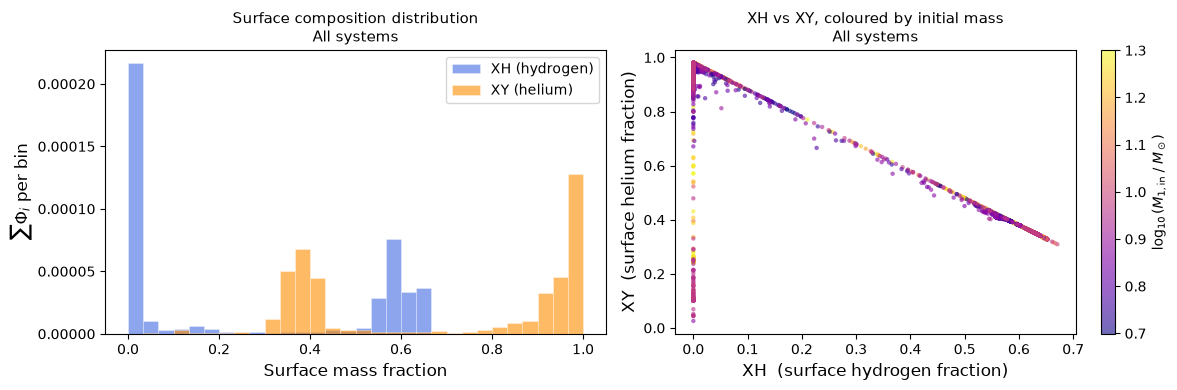

IMF-weighted mean XH = 0.2652
IMF-weighted mean XY = 0.6880
Fraction of selection with XH < 0.1 (envelope-stripped): 0.0002


In [37]:
XH_sel   = XH[mask]
XY_sel   = XY[mask]
M1in_sel = M1in[mask]
Phi_sel  = Phi[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left panel: overlaid histograms ---
ax = axes[0]
bins = np.linspace(0, 1, 31)
ax.hist(XH_sel, bins=bins, weights=Phi_sel,
        color='royalblue', alpha=0.6, edgecolor='white', linewidth=0.4, label='XH (hydrogen)')
ax.hist(XY_sel, bins=bins, weights=Phi_sel,
        color='darkorange', alpha=0.6, edgecolor='white', linewidth=0.4, label='XY (helium)')
ax.set_xlabel('Surface mass fraction', fontsize=12)
ax.set_ylabel(r'$\sum \Phi_i$ per bin', fontsize=12)
ax.set_title(f'Surface composition distribution\n{pop_label}', fontsize=11)
ax.legend()

# --- Right panel: XH vs XY scatter coloured by M1in ---
ax = axes[1]
sc = ax.scatter(XH_sel, XY_sel, c=np.log10(M1in_sel),
                cmap='plasma', s=10, alpha=0.6, linewidths=0)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$\log_{10}(M_{1,\mathrm{in}} \;/\; M_\odot)$', fontsize=10)
ax.set_xlabel('XH  (surface hydrogen fraction)', fontsize=12)
ax.set_ylabel('XY  (surface helium fraction)', fontsize=12)
ax.set_title(f'XH vs XY, coloured by initial mass\n{pop_label}', fontsize=11)

plt.tight_layout()
plt.show()

# Weighted means
mean_XH = np.average(XH_sel, weights=Phi_sel)
mean_XY = np.average(XY_sel, weights=Phi_sel)
print(f'IMF-weighted mean XH = {mean_XH:.4f}')
print(f'IMF-weighted mean XY = {mean_XY:.4f}')
print(f'Fraction of selection with XH < 0.1 (envelope-stripped): '
      f'{Phi_sel[XH_sel < 0.1].sum():.4f}')

---
## Summary & further exploration

You have now:
- Chosen a **population type** (single stars, close binaries, or all systems)
- Applied an **IMF weighting** normalised over that population
- Selected a **sub-sample** using physically motivated constraints
- Quantified the **IMF-weighted fraction** your selection represents
- Examined the **age** and **surface composition** distributions

### Things to try next
- Switch `POPULATION` between `'single'`, `'close'`, and `'all'` — how do the distributions change?
- Vary `alpha` or the upper mass limit in the IMF and note how the weighted mean age and composition shift
- Select only **stripped-envelope stars** (`XH < 0.01`) — are they more common in close binaries?
- Compare the `HeCore` and `COCore` masses between populations.
- Modify the IMF normalisation integral to properly take into account mass grid spacing for single stars.
- Try different metallicities (z001, z010, z020)
- Consider selecting out stars which will undergo core collapse supernovae (e.g. by mass range or by core mass) and look at their surface compositions.
- If you're feeling _very_ brave, think about weighting the models by binary fraction, period and mass ratio distributions (see Moe & di Stefano 2017).
